In [28]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from IPython.display import display, Image

# Import project modules
from models import MLP_MNIST, MLP_Encoder_Decoder, SemanticCommSystem
from attacks.fgsm import fgsm_attack
from attacks.pgd import pgd_attack_semantic
from attacks.semantic_attack import end_to_end_attack
from attacks.evaluate import visualize_attack, evaluate_semantic_attack

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using device: cpu


## Load Models and Data
Load the pre-trained semantic communication models (Encoder, Decoder, Classifier) and MNIST test data.

In [1]:
# Configuration
COMPRESSION_RATE = 0.1
BATCH_SIZE = 100 # Use more images for evaluation statistics
VIS_SAMPLES = 5  # Number of images to visualize

# Load Data
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='semantic_extraction/dataset/mnist', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Get a batch of images
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Load Models
def load_models(compression_rate):
    # Initialize models
    channel = int(compression_rate * 784)
    # The saved models use 6 decimal places in the filename
    model_path_coder = f'saved_model/MLP_MNIST_coder_{compression_rate:.6f}.pkl'
    model_path_classifier = 'saved_model/MLP_MNIST.pkl'
    
    # Load Encoder/Decoder
    coder = MLP_Encoder_Decoder(channel=channel).to(device)
    if os.path.exists(model_path_coder):
        coder.load_state_dict(torch.load(model_path_coder, map_location=device))
        print(f"Loaded Coder from {model_path_coder}")
    else:
        print(f"Error: Coder model not found at {model_path_coder}")
        
    # Load Classifier
    classifier = MLP_MNIST().to(device)
    if os.path.exists(model_path_classifier):
        classifier.load_state_dict(torch.load(model_path_classifier, map_location=device))
        print(f"Loaded Classifier from {model_path_classifier}")
    else:
        print(f"Error: Classifier model not found at {model_path_classifier}")
        
    coder.eval()
    classifier.eval()

    # Return the objects as is, consistent with attacks.py
    return coder, classifier

coder, classifier = load_models(COMPRESSION_RATE)
print("Models loaded successfully.")

NameError: name 'transforms' is not defined

## 1. FGSM Attack Demo
Fast Gradient Sign Method (FGSM) is a one-step gradient-based attack. Here we use `epsilon=0.2`.

Running FGSM Attack...

FGSM Attack Metrics:
clean_accuracy: 0.9700 (97/100)
adversarial_accuracy: 0.3900 (38/100)
attack_success_rate: 0.6100 (61/100)
perturbation_l2_mean: 4.0862
perturbation_linf_max: 0.2000
psnr: 16.7117
semantic_l2_distance: 0.0961
FGSM Attack Visualization


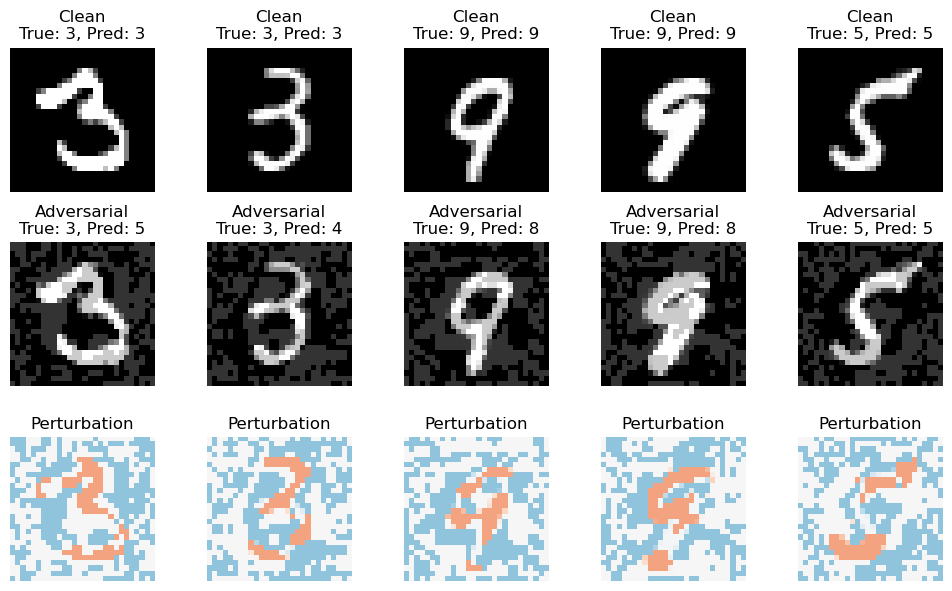

In [31]:
print("Running FGSM Attack...")
epsilon = 0.2

# Create End-to-End Model for FGSM (consistent with attacks.py usage)
full_model = SemanticCommSystem(coder, classifier).to(device)

# Run Attack
# fgsm_attack returns (adv_images, perturbation)
adv_images_fgsm, _ = fgsm_attack(
    full_model,
    images, labels,
    epsilon=epsilon
)

# Evaluate
metrics_fgsm = evaluate_semantic_attack(
    coder.encode, coder.decode, classifier,
    images, adv_images_fgsm, labels, device
)

print("\nFGSM Attack Metrics:")
for k, v in metrics_fgsm.items():
    if k in ['clean_accuracy', 'adversarial_accuracy', 'attack_success_rate']:
         print(f"{k}: {v:.4f} ({int(v*len(images))}/{len(images)})")
    else:
        print(f"{k}: {v:.4f}")

# Visualize
with torch.no_grad():
    # Get predictions
    sem_clean = coder.encode(images)
    rec_clean = coder.decode(sem_clean)
    pred_clean = classifier(rec_clean).argmax(dim=1)
    
    sem_adv = coder.encode(adv_images_fgsm)
    rec_adv = coder.decode(sem_adv)
    pred_adv = classifier(rec_adv).argmax(dim=1)

visualize_attack(
    images, adv_images_fgsm, labels.cpu(),
    pred_clean.cpu(), pred_adv.cpu(),
    num_samples=VIS_SAMPLES
)
print("FGSM Attack Visualization")
plt.show()

## 2. PGD Attack Demo
Projected Gradient Descent (PGD) is a multi-step iterative attack. Here we use `epsilon=0.2`, `alpha=0.01`, `num_iter=40`.

Running PGD Attack (epsilon=0.2, alpha=0.01, iterations=40)...

PGD Attack Metrics:
clean_accuracy: 0.9700 (97/100)
adversarial_accuracy: 0.0200 (1/100)
attack_success_rate: 0.9800 (98/100)
perturbation_l2_mean: 3.9142
perturbation_linf_max: 0.2000
psnr: 17.0854
semantic_l2_distance: 0.0928
PGD Attack Visualization


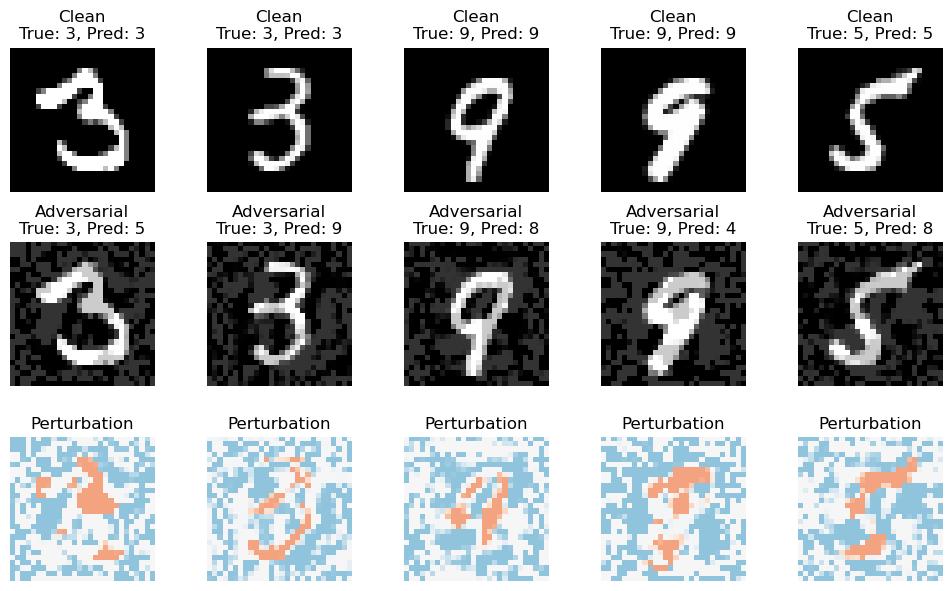

In [32]:
from attacks.pgd import pgd_attack_semantic

epsilon = 0.2
alpha = 0.01
num_iter = 40

print(f"Running PGD Attack (epsilon={epsilon}, alpha={alpha}, iterations={num_iter})...")
# pgd_attack_semantic handles method passing correctly using hasattr checks
adv_pgd, _ = pgd_attack_semantic(
    coder.encode, 
    coder.decode, 
    classifier, 
    images, 
    labels, 
    epsilon=epsilon, 
    alpha=alpha, 
    num_iter=num_iter
)

# Evaluate
metrics_pgd = evaluate_semantic_attack(
    coder.encode, coder.decode, classifier,
    images, adv_pgd, labels, device
)

print("\nPGD Attack Metrics:")
for k, v in metrics_pgd.items():
    if k in ['clean_accuracy', 'adversarial_accuracy', 'attack_success_rate']:
         print(f"{k}: {v:.4f} ({int(v*len(images))}/{len(images)})")
    else:
        print(f"{k}: {v:.4f}")

# Visualize
with torch.no_grad():
    # Get predictions
    sem_clean = coder.encode(images)
    rec_clean = coder.decode(sem_clean)
    pred_clean = classifier(rec_clean).argmax(dim=1)
    
    sem_adv = coder.encode(adv_pgd)
    rec_adv = coder.decode(sem_adv)
    pred_adv = classifier(rec_adv).argmax(dim=1)

visualize_attack(
    images, adv_pgd, labels.cpu(),
    pred_clean.cpu(), pred_adv.cpu(),
    num_samples=VIS_SAMPLES
)
# Note: visualize_attack does not take a 'title' argument
print("PGD Attack Visualization")
plt.show()

## 3. End-to-End Semantic Attack Demo
This attack targets the entire communication pipeline (Encoder -> Channel -> Decoder -> Classifier). Using `epsilon=0.2`.

Running End-to-End Semantic Attack (epsilon=0.2)...

End-to-End Semantic Attack Metrics:
clean_accuracy: 0.9700 (97/100)
adversarial_accuracy: 0.5300 (52/100)
attack_success_rate: 0.4700 (46/100)
perturbation_l2_mean: 1.8172
perturbation_linf_max: 0.2000
psnr: 20.6322
semantic_l2_distance: 0.0611
End-to-End Semantic Attack Visualization


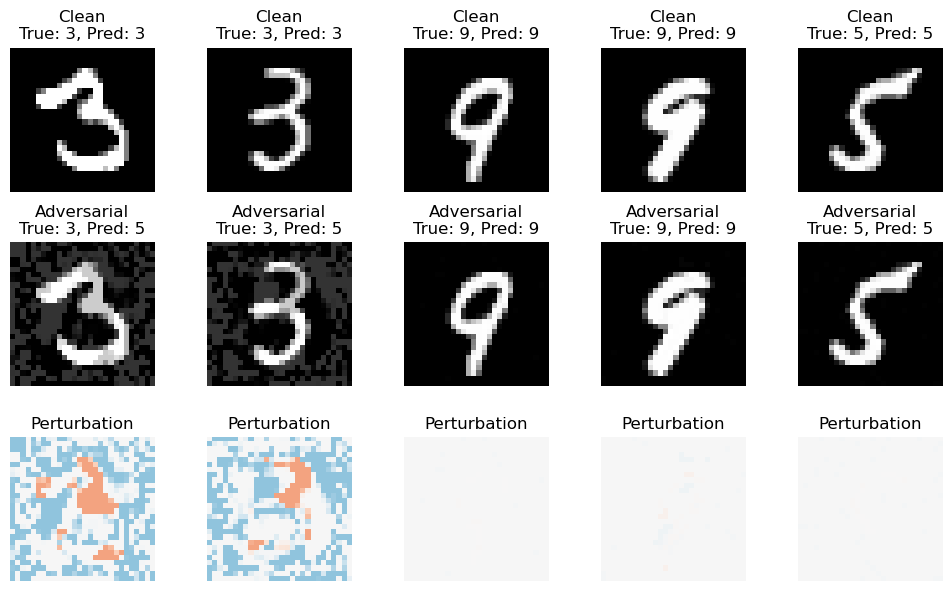

In [33]:
from attacks.semantic_attack import end_to_end_attack

epsilon = 0.2
print(f"Running End-to-End Semantic Attack (epsilon={epsilon})...")

# end_to_end_attack handles method passing correctly using hasattr checks
adv_e2e, _, _ = end_to_end_attack(
    coder.encode, 
    coder.decode, 
    classifier, 
    images, 
    labels, 
    epsilon=epsilon,
    num_iter=40
)

# Evaluate
metrics_e2e = evaluate_semantic_attack(
    coder.encode, coder.decode, classifier,
    images, adv_e2e, labels, device
)

print("\nEnd-to-End Semantic Attack Metrics:")
for k, v in metrics_e2e.items():
    if k in ['clean_accuracy', 'adversarial_accuracy', 'attack_success_rate']:
         print(f"{k}: {v:.4f} ({int(v*len(images))}/{len(images)})")
    else:
        print(f"{k}: {v:.4f}")

# Visualize
with torch.no_grad():
    # Get predictions
    sem_clean = coder.encode(images)
    rec_clean = coder.decode(sem_clean)
    pred_clean = classifier(rec_clean).argmax(dim=1)
    
    sem_adv = coder.encode(adv_e2e)
    rec_adv = coder.decode(sem_adv)
    pred_adv = classifier(rec_adv).argmax(dim=1)

visualize_attack(
    images, adv_e2e, labels.cpu(),
    pred_clean.cpu(), pred_adv.cpu(),
    num_samples=VIS_SAMPLES
)
# Note: visualize_attack does not take a 'title' argument
print("End-to-End Semantic Attack Visualization")
plt.show()

## 4. Statistical Analysis
Below are the statistical results from our comprehensive experiments, showing the effectiveness of different attacks across varying epsilon values and compression rates.

Generating charts inside notebook...
Loading experiment results...

Generating charts in results...
Saved: results/attack_comparison.png
Saved: results/epsilon_curves.png
Saved: results/psnr_tradeoff.png
Saved: results/perturbation_comparison.png
All charts saved to results
Showing key experiment charts...


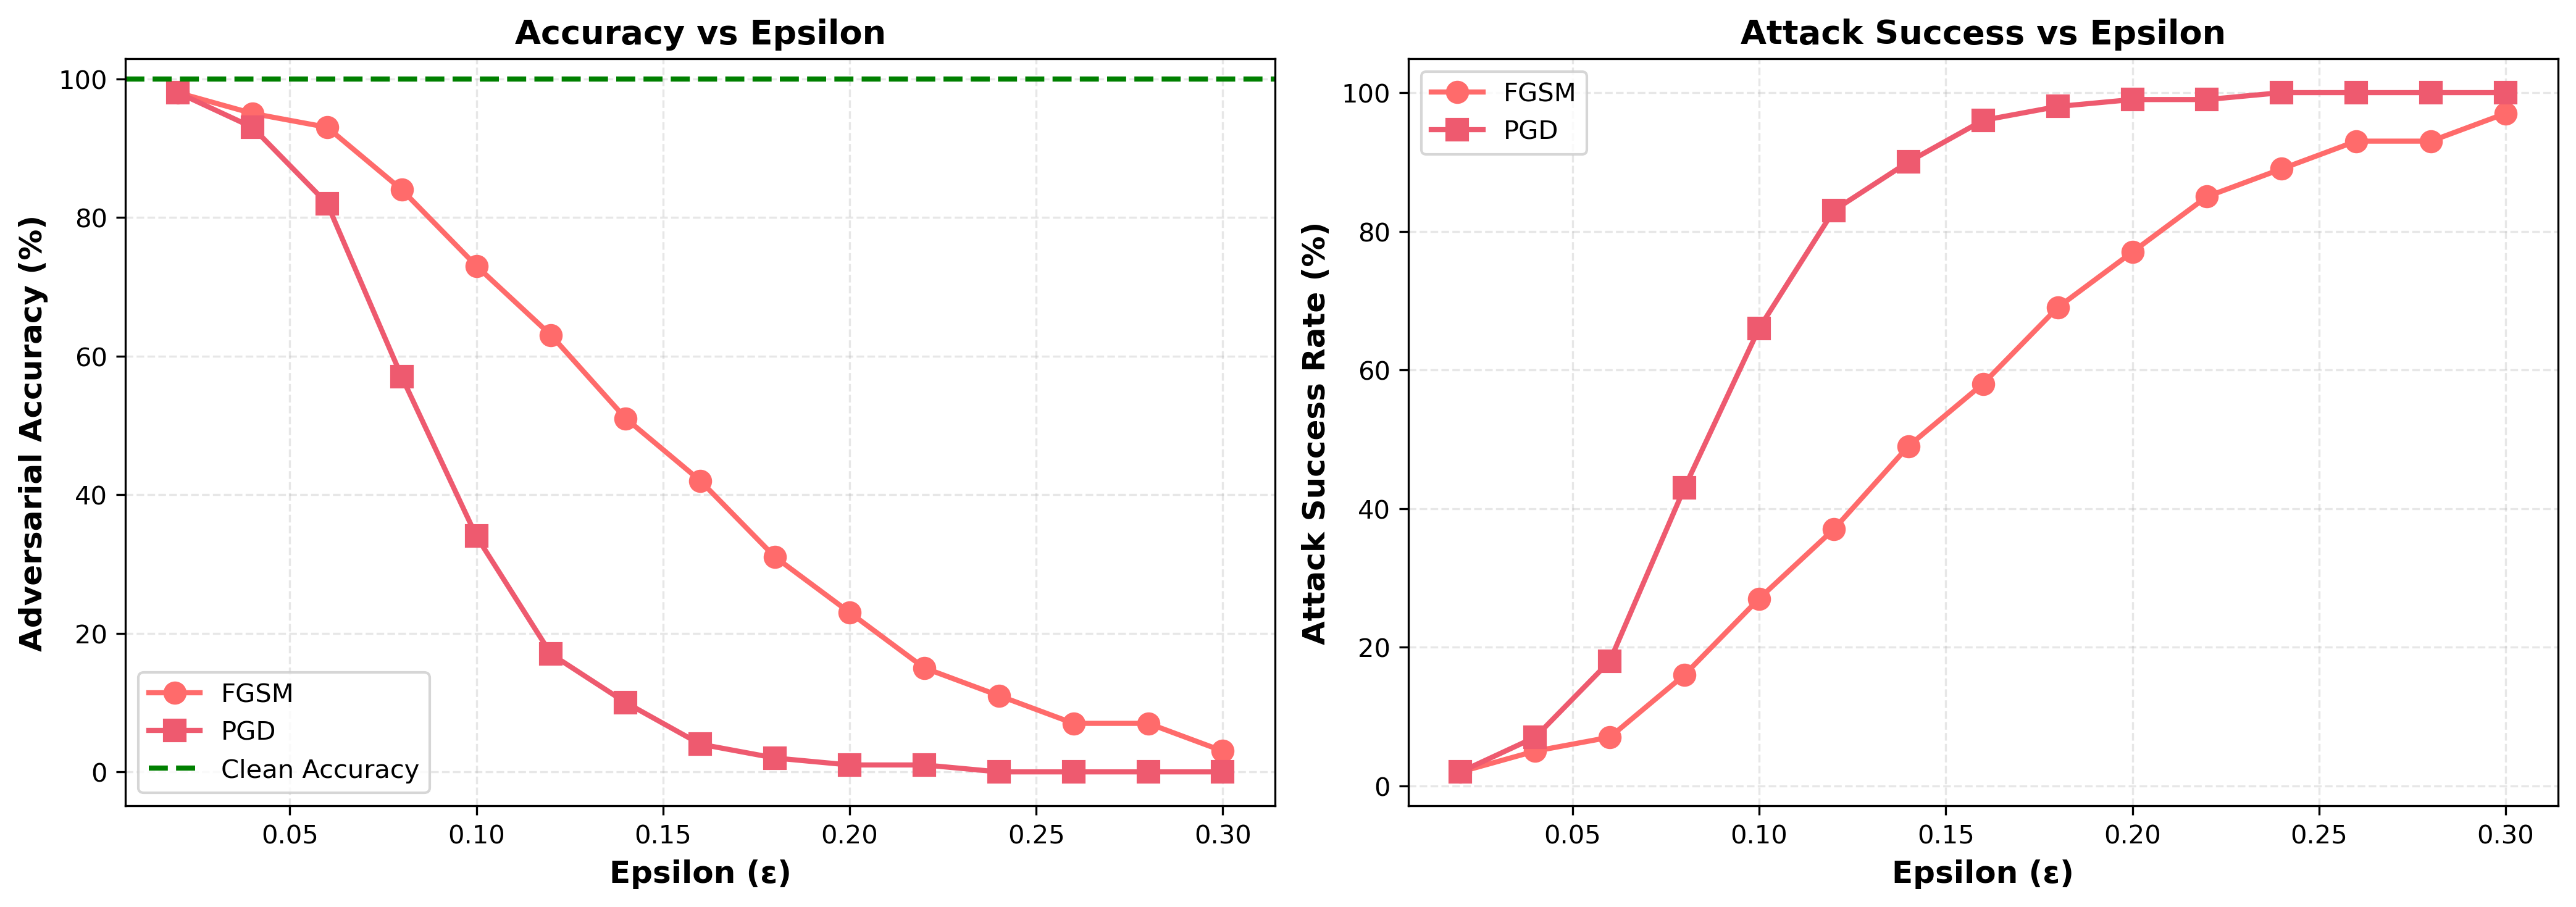

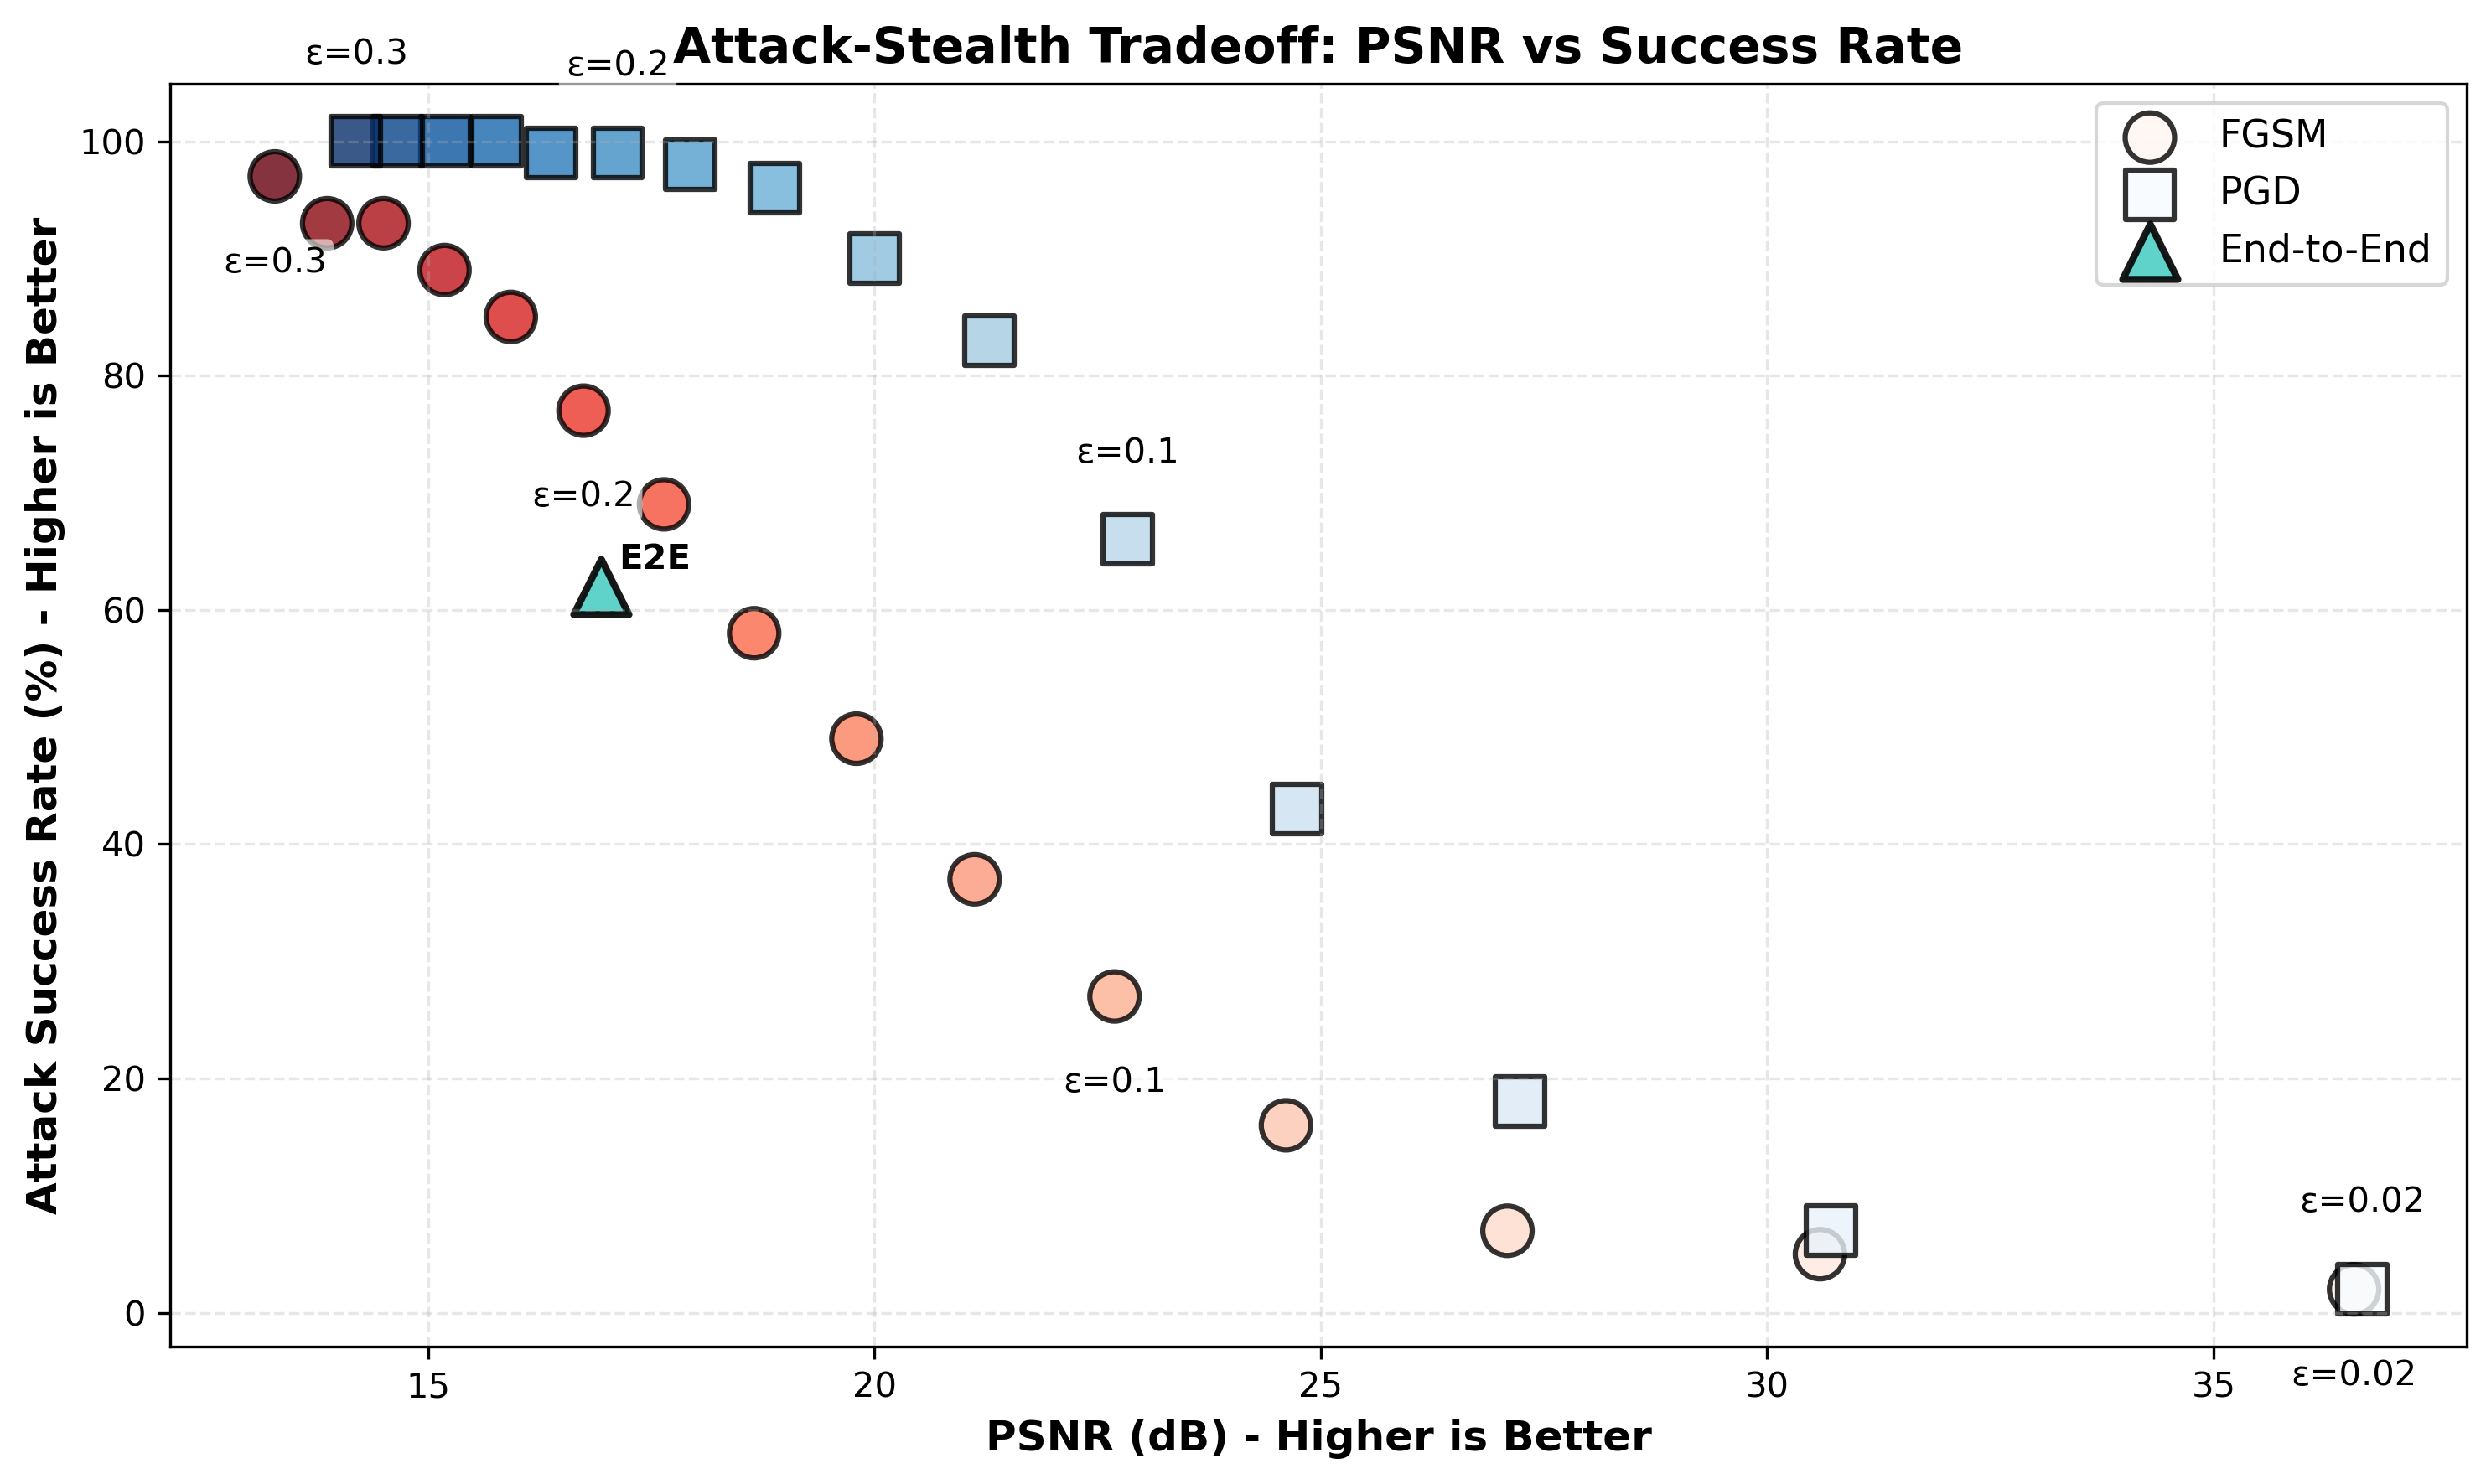

In [37]:
from IPython.display import Image, display
import generate_charts

print("Generating charts inside notebook...")
generate_charts.generate_all_charts('results/experiment_results.json', 'results')

print("Showing key experiment charts...")
display(Image(filename='results/epsilon_curves.png'))
display(Image(filename='results/psnr_tradeoff.png'))